# Assignment 1 - Gathering data by downloading a file

## Topic 19 - The Data Analytics Process

### Scenario

You have been asked to prepare a short evidence brief about how one indicator has changed over time in Ghana compared with two other countries. Nobody will hand you a spreadsheet. You have to find the data at a public URL, download it with Python, keep a record of where it came from, clean it, save it, and produce two charts that support your conclusion.

This is the ordinary first day of an analyst's project, and it is the whole point of this assignment. A polished chart built on data of unknown origin is worth nothing. A modest chart built on data whose source, retrieval date, and cleaning steps are all documented is professional work.

### What you are practising

| Skill | Where it appears |
|---|---|
| Downloading a file with `urllib.request` | Part 3 |
| Downloading the same file with `requests` | Part 3 |
| Writing your own reusable functions | Every part |
| Recording provenance with a checksum | Part 4 |
| Inspecting and cleaning data with pandas | Parts 5 and 6 |
| Separating raw data from cleaned data | Part 7 |
| Grouping and summarising with pandas | Part 8 |
| Line and bar charts with matplotlib | Part 9 |
| Submitting work with Git and GitHub | Part 12 |

## What you must submit

A GitHub repository named **`itfy-data-gathering-download`** containing:

1. this notebook, completed, **run from top to bottom so all outputs and charts are visible**;
2. `data/raw/` - the file exactly as you downloaded it, unchanged;
3. `data/clean/` - the cleaned dataset you saved;
4. `README.md` - your research question, source details, findings, and limitations;
5. a manifest file recording where the data came from.

Part 12 of this notebook explains exactly how to submit. If you have never used GitHub, work through [the GitHub submission guide](../topic19d_appendix_submitting_with_github.ipynb) first - it assumes no previous experience and is written for Windows.

### Rules

- **Every function skeleton must be completed.** Do not replace a function with loose code in a cell. Writing functions is being assessed directly.
- **Do not edit the raw downloaded file.** All cleaning happens in pandas and is saved to a separate file.
- **Charts are limited to line and bar** for the graded parts. Part 10 is optional space to explore other chart types if you wish.
- **Explain your results in words.** Every part has a markdown cell for your explanation. A correct number with no interpretation earns half the marks.
- **No API keys, passwords, or personal data** anywhere in the repository.

## How to work through this notebook

Each part follows the same three-step shape:

1. **Read** the explanation and the worked example.
2. **Complete** the function skeleton. Anywhere you see `# TODO`, replace it with your code. Anywhere you see `raise NotImplementedError(...)`, delete that line once your function works.
3. **Run** the check cell underneath, which tells you whether your function behaves as expected.

Work in order. Later parts use the variables and functions you create in earlier ones. If a cell fails, read the error message before changing anything - the message almost always names the problem.

---
## Part 1 - Set up your workspace

Run the cell below without changing it. It imports what you need and creates the folders your work will live in.

Two things to notice, because you will need both in your own projects:

- `pathlib.Path` builds file paths that work on Windows, macOS, and Linux. Writing `DATA_DIR / "raw"` is correct everywhere, whereas typing `"data\raw"` breaks on anything that is not Windows and can misbehave even there because `\r` means something special in Python strings.
- The `try`/`except ImportError` around `requests` means this notebook still runs if `requests` is not installed. You will install it in Part 3.

In [1]:
# Run this cell as it is. Do not change it.
from pathlib import Path
from datetime import datetime, timezone
from urllib.request import Request, urlopen
from urllib.error import HTTPError, URLError
import hashlib
import json

import pandas as pd
import matplotlib.pyplot as plt

# requests is optional at this point. Part 3 shows you how to install it.
try:
    import requests
    REQUESTS_AVAILABLE = True
except ImportError:
    REQUESTS_AVAILABLE = False

# ---- Folders -----------------------------------------------------------------
# Everything is written relative to this notebook, so the repository you submit
# is self-contained and runs on somebody else's computer.
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / "data"
RAW_DIR = DATA_DIR / "raw"        # never edit anything in here
CLEAN_DIR = DATA_DIR / "clean"    # your cleaned output goes here
CHART_DIR = BASE_DIR / "charts"   # saved chart images, if you save any

for folder in (RAW_DIR, CLEAN_DIR, CHART_DIR):
    folder.mkdir(parents=True, exist_ok=True)

# ---- Display settings --------------------------------------------------------
pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 120)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 110

# A polite identifier. Some servers reject requests that do not say who they are.
USER_AGENT = "ITFY-Ghana-student-assignment/1.0"

print("pandas version:     ", pd.__version__)
print("requests available: ", REQUESTS_AVAILABLE)
print("raw data folder:    ", RAW_DIR)
print("clean data folder:  ", CLEAN_DIR)

pandas version:      3.0.5
requests available:  True
raw data folder:     /home/jovyan/work/notebooks/data_analysis_process/assignments/data/raw
clean data folder:   /home/jovyan/work/notebooks/data_analysis_process/assignments/data/clean


---
## Part 2 - Choose your dataset and write your question

Three datasets are offered below. **Choose one.** All three are public, free, published by a recognised organisation, and small enough to download in seconds.

### Option A - Gapminder five-year country indicators

| Item | Detail |
|---|---|
| Direct file URL | `https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv` |
| Publisher | Gapminder Foundation, distributed in the Plotly datasets collection |
| Size | About 82 KB, 1,704 rows, 6 columns |
| Columns | `country`, `year`, `pop`, `continent`, `lifeExp`, `gdpPercap` |
| What one row is | One country in one year |
| Coverage | 142 countries, 1952 to 2007, every five years |
| Documentation | https://www.gapminder.org/data/documentation/ |
| Cleaning you will face | Column names are abbreviated and inconsistent; population is stored as a float |

### Option B - Our World in Data life expectancy

| Item | Detail |
|---|---|
| Direct file URL | `https://ourworldindata.org/grapher/life-expectancy.csv` |
| Publisher | Our World in Data, based on the UN World Population Prospects and historical sources |
| Size | About 590 KB, 21,565 rows, 4 columns |
| Columns | `Entity`, `Code`, `Year`, `Life expectancy` |
| What one row is | One entity in one year |
| Coverage | Countries and regions, 1543 to 2023 |
| Documentation | https://ourworldindata.org/life-expectancy |
| Cleaning you will face | `Entity` mixes countries with aggregates such as `Africa` and `World`; those aggregate rows have a missing `Code`. Early years are sparse historical estimates. Column names contain spaces and capital letters. |

### Option C - World Bank GDP by country and year

| Item | Detail |
|---|---|
| Direct file URL | `https://raw.githubusercontent.com/datasets/gdp/main/data/gdp.csv` |
| Publisher | World Bank development indicators, redistributed by the Frictionless Data project |
| Size | About 550 KB, 13,979 rows, 4 columns |
| Columns | `Country Name`, `Country Code`, `Year`, `Value` |
| What one row is | One country in one year |
| Coverage | 1960 to 2023, GDP in current US dollars |
| Documentation | https://datahub.io/core/gdp |
| Cleaning you will face | The measure is called `Value`, which tells the reader nothing - you must rename it and record its unit. Values are very large, so a chart is unreadable until you convert to billions. `Country Name` includes aggregates such as `World` and `Euro area`. |

### Choosing well

Option A is the gentlest. Option B has the most interesting cleaning problem, because separating real countries from regional aggregates is a judgement you have to make and defend. Option C forces you to think about units, which is where a lot of real analysis goes wrong.

Whichever you choose, your question must **compare Ghana with at least two other countries over time**, because Part 9 asks for a line chart of change and a bar chart of a ranking.

Good question: *How did life expectancy in Ghana change between 1960 and 2023 compared with Kenya and Senegal?*

Poor question: *What is in this dataset?* That is not a question, it is a description.

In [2]:
# The three options are defined for you. Read them, then set CHOSEN_OPTION below.
DATASET_OPTIONS = {
    "A": {
        "name": "Gapminder five-year country indicators",
        "url": "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv",
        "raw_filename": "gapminder_five_year_raw.csv",
        "publisher": "Gapminder Foundation, distributed in the Plotly datasets collection",
        "documentation": "https://www.gapminder.org/data/documentation/",
        "row_meaning": "one country in one year",
        "country_column": "country",
        "year_column": "year",
        "value_column": "lifeExp",
        "value_unit": "years",
    },
    "B": {
        "name": "Our World in Data life expectancy",
        "url": "https://ourworldindata.org/grapher/life-expectancy.csv",
        "raw_filename": "owid_life_expectancy_raw.csv",
        "publisher": "Our World in Data",
        "documentation": "https://ourworldindata.org/life-expectancy",
        "row_meaning": "one entity in one year",
        "country_column": "Entity",
        "year_column": "Year",
        "value_column": "Life expectancy",
        "value_unit": "years",
    },
    "C": {
        "name": "World Bank GDP by country and year",
        "url": "https://raw.githubusercontent.com/datasets/gdp/main/data/gdp.csv",
        "raw_filename": "world_bank_gdp_raw.csv",
        "publisher": "World Bank (redistributed by Frictionless Data / datahub.io)",
        "documentation": "https://datahub.io/core/gdp",
        "row_meaning": "one country in one year",
        "country_column": "Country Name",
        "year_column": "Year",
        "value_column": "Value",
        "value_unit": "current US dollars",
    },
}
CHOSEN_OPTION = "A"

RESEARCH_QUESTION = (
    "How has life expectancy in Ghana changed between 1952 and 2007 "
    "compared with Kenya, Nigeria, and South Africa?"
)

FOCUS_COUNTRIES = ["Ghana", "Kenya", "Nigeria", "South Africa"]

START_YEAR = 1952
END_YEAR = 2007

EXPECTATION = (
    "I expect life expectancy to increase in all four countries over time, "
    "although the rate of improvement may differ because of differences in "
    "health, economic, and social conditions."
)
# ---- Do not change below this line -------------------------------------------
if CHOSEN_OPTION not in DATASET_OPTIONS:
    raise ValueError('Set CHOSEN_OPTION to "A", "B", or "C" before continuing.')

DATASET = DATASET_OPTIONS[CHOSEN_OPTION]
SOURCE_URL = DATASET["url"]
RAW_PATH = RAW_DIR / DATASET["raw_filename"]

print("Dataset:  ", DATASET["name"])
print("URL:      ", SOURCE_URL)
print("Raw file: ", RAW_PATH)
print("Question: ", RESEARCH_QUESTION or "*** still empty ***")
print("Countries:", FOCUS_COUNTRIES)
print("Years:    ", START_YEAR, "to", END_YEAR)

Dataset:   Gapminder five-year country indicators
URL:       https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv
Raw file:  /home/jovyan/work/notebooks/data_analysis_process/assignments/data/raw/gapminder_five_year_raw.csv
Question:  How has life expectancy in Ghana changed between 1952 and 2007 compared with Kenya, Nigeria, and South Africa?
Countries: ['Ghana', 'Kenya', 'Nigeria', 'South Africa']
Years:     1952 to 2007


In [3]:
DATASET = DATASET_OPTIONS[CHOSEN_OPTION]
print(list(DATASET.keys()))

['name', 'url', 'raw_filename', 'publisher', 'documentation', 'row_meaning', 'country_column', 'year_column', 'value_column', 'value_unit']


---
## Part 3 - Download the file, two ways

A URL is just an address. When you type a data URL into a browser, the browser downloads bytes and shows them to you. Python can request exactly the same bytes, and this is better than clicking a download button, because code can be re-run, read by somebody else, and checked.

You will do this twice, with the two tools Python analysts actually use.

| | `urllib.request` | `requests` |
|---|---|---|
| Comes with Python | Yes, always available | No, must be installed |
| Typical lines of code | More | Fewer |
| Reading the status code | `response.status` | `response.status_code` |
| Getting the body as bytes | `response.read()` | `response.content` |
| Getting the body as text | `response.read().decode("utf-8")` | `response.text` |
| Parsing JSON | `json.load(response)` | `response.json()` |
| Errors | Raises `HTTPError` for 404, 500, and similar | Returns normally; you call `response.raise_for_status()` |

Neither is wrong. `urllib` is guaranteed to exist, which matters on a locked-down work computer. `requests` is shorter and clearer, which is why most teams install it.

### Installing requests

If the setup cell printed `requests available: False`, open a terminal and run:

```text
pip install requests
```

In VS Code you can also run it from a notebook cell by putting an exclamation mark in front: `!pip install requests`. After installing, restart the kernel and run the setup cell again.

### Worked example - the shape of both

Read this example carefully. It downloads a small file with each tool. You are not asked to change it, and you may run it: it writes to a scratch filename that is not part of your submission.

In [4]:
# WORKED EXAMPLE - read this, run it, then write your own versions below.
EXAMPLE_URL = "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv"
EXAMPLE_PATH = RAW_DIR / "_example_download.csv"

# ---- With urllib.request (standard library) ----------------------------------
# Request() lets us attach headers. urlopen() sends it and returns a response
# object that behaves like an open file, so we .read() it to get bytes.
example_request = Request(EXAMPLE_URL, headers={"User-Agent": USER_AGENT})
with urlopen(example_request, timeout=30) as response:
    print("urllib status code: ", response.status)
    print("urllib content type:", response.headers.get("Content-Type"))
    downloaded_bytes = response.read()

# "wb" means write bytes. We save exactly what the server sent, with no
# decoding or editing, because this file is our evidence of what we received.
EXAMPLE_PATH.write_bytes(downloaded_bytes)
print(f"urllib saved {len(downloaded_bytes):,} bytes to {EXAMPLE_PATH.name}")

# ---- With requests (third-party) --------------------------------------------
if REQUESTS_AVAILABLE:
    response = requests.get(EXAMPLE_URL, headers={"User-Agent": USER_AGENT}, timeout=30)
    response.raise_for_status()   # turns a 404 or 500 into an exception
    print("\nrequests status code: ", response.status_code)
    print("requests content type:", response.headers.get("Content-Type"))
    print(f"requests received {len(response.content):,} bytes")
else:
    print("\nrequests is not installed yet - see the instructions above.")

# ---- The first two lines of what we received --------------------------------
print("\nFirst two lines of the file:")
for line in downloaded_bytes.decode("utf-8").splitlines()[:2]:
    print("   ", line)

urllib status code:  200
urllib content type: text/plain; charset=utf-8
urllib saved 82,079 bytes to _example_download.csv

requests status code:  200
requests content type: text/plain; charset=utf-8
requests received 82,079 bytes

First two lines of the file:
    country,year,pop,continent,lifeExp,gdpPercap
    Afghanistan,1952,8425333,Asia,28.801,779.4453145


### Now write your own download functions

Complete the two functions below. They must behave identically apart from the tool they use.

Both functions should:

1. skip the download if the file already exists and `force` is `False`, and print that it is using the cached copy - this is politeness to the server and speed for you;
2. send the `User-Agent` header;
3. use a timeout, so a dead server cannot hang your notebook forever;
4. check that the download succeeded before writing anything;
5. write the bytes to `destination` **without modifying them**;
6. return a dictionary describing what happened.

Notice that the functions **return** their result rather than printing it. A function that only prints cannot be used by the next step of your pipeline. This is the single most common mistake beginners make when writing functions, and Part 4 depends on you getting it right.

In [5]:
def download_with_urllib(url, destination, force=False, timeout=30):
    """Download a file using the standard library and return provenance details."""
    destination = Path(destination)

    # TODO 6: Use cached copy if the file already exists
    if destination.exists() and not force:
        print(f"Using cached copy: {destination}")
        return {
            "tool": "urllib",
            "url": url,
            "path": str(destination),
            "bytes": destination.stat().st_size,
            "status": None,
            "retrieved_utc": datetime.now(timezone.utc).isoformat(),
            "from_cache": True
        }

    # TODO 7: Download using urllib
    request = Request(
        url,
        headers={"User-Agent": USER_AGENT}
    )

    try:
        with urlopen(request, timeout=timeout) as response:
            downloaded_bytes = response.read()
            status = response.status

    except (HTTPError, URLError) as error:
        raise RuntimeError(
            f"Failed to download URL with urllib: {url}"
        ) from error

    # TODO 8: Save the bytes without modifying them
    destination.write_bytes(downloaded_bytes)

    # TODO 9: Return provenance details
    return {
        "tool": "urllib",
        "url": url,
        "path": str(destination),
        "bytes": len(downloaded_bytes),
        "status": status,
        "retrieved_utc": datetime.now(timezone.utc).isoformat(),
        "from_cache": False
    }


def download_with_requests(url, destination, force=False, timeout=30):
    """Download a file using the requests library and return provenance details."""

    if not REQUESTS_AVAILABLE:
        raise RuntimeError(
            "requests is not installed. Run: pip install requests"
        )

    destination = Path(destination)

    # TODO 10: Use cached copy if the file already exists
    if destination.exists() and not force:
        print(f"Using cached copy: {destination}")
        return {
            "tool": "requests",
            "url": url,
            "path": str(destination),
            "bytes": destination.stat().st_size,
            "status": None,
            "retrieved_utc": datetime.now(timezone.utc).isoformat(),
            "from_cache": True
        }

    # TODO 11: Download using requests
    try:
        response = requests.get(
            url,
            headers={"User-Agent": USER_AGENT},
            timeout=timeout
        )
        response.raise_for_status()

    except requests.RequestException as error:
        raise RuntimeError(
            f"Failed to download URL with requests: {url}"
        ) from error

    # TODO 12: Save the bytes without modifying them
    destination.write_bytes(response.content)

    return {
        "tool": "requests",
        "url": url,
        "path": str(destination),
        "bytes": len(response.content),
        "status": response.status_code,
        "retrieved_utc": datetime.now(timezone.utc).isoformat(),
        "from_cache": False
    }

In [6]:

# Path for the urllib download
RAW_PATH = RAW_DIR / DATASET["raw_filename"]

# TODO 13: Downloading my chosen dataset with urllib
urllib_provenance = download_with_urllib(
    DATASET["url"],
    RAW_PATH
)

print(urllib_provenance)


# TODO 14: Download the same file with requests
requests_path = RAW_DIR / ("requests_" + DATASET["raw_filename"])

requests_provenance = download_with_requests(
    DATASET["url"],
    requests_path
)


{'tool': 'urllib', 'url': 'https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv', 'path': '/home/jovyan/work/notebooks/data_analysis_process/assignments/data/raw/gapminder_five_year_raw.csv', 'bytes': 82079, 'status': 200, 'retrieved_utc': '2026-09-08T23:26:03.664236+00:00', 'from_cache': False}


### Your answer - compare the two tools

Complete this table from your own experience of writing the two functions. Replace the bracketed prompts with your own words.

| Question | Your answer |
|---|---|
| Which function took more lines of code, and why? |download_with_urllib took more lines because urllib is part of Python's standard library and requires more code to create the request, open the connection, read the response, and handle different errors.] |
| How did each one tell you the request had succeeded? |urllib checked the response using response.status, while requests used response.raise_for_status() and then checked response.status_code. A successful request normally has status code 200.] |
| Which would you use on a computer where you cannot install packages, and why? | [I would use urllib because it is included in Python's standard library, so no additional package needs to be installed. |
| Which produced the clearer error message when something went wrong? |requests produced the clearer error handling because raise_for_status() automatically identifies HTTP errors such as 404 or 500.] |
| Did the two downloads produce identical files? What does that tell you? |Yes, the two downloads produced the same number of bytes. This shows that the download tool did not modify the file |

**Then try this deliberately.** Change one character in the URL so that it is wrong, call one of your functions, and read the error. Write down below what the error said and which line of your function raised it. Handling a broken source is a normal part of gathering data, and an analyst who has never seen the error message will not recognise it under pressure.

The error was HTTPError: HTTP Error 404: Not Found. This means the server could not find the file at the URL I provided. The error was raised when urlopen() tried to open the incorrect URL, at the line with urlopen(example_request, timeout=30) as response:.]

---
## Part 4 - Record where the data came from

You now have a file. In six months, will you remember which URL produced it, or which day you downloaded it? The file itself does not record either fact.

**Provenance** is the record of where data came from. At minimum, keep the source URL, the retrieval time, the local filename, the publisher, and a **checksum**.

A checksum is a short fingerprint calculated from the contents of a file. The SHA-256 algorithm reads every byte and produces a 64-character string. Change a single digit anywhere in the file and the fingerprint changes completely. This is what lets you prove that the file you are analysing today is the same file you downloaded last month - useful when a publisher revises a dataset without changing its filename.

A checksum does not tell you the data is *correct*. It only tells you the data is *unchanged*.

In [7]:
def file_fingerprint(path):
    """Return the SHA-256 checksum of a file as a 64-character string.

    Read the file in chunks rather than all at once, so that this function works
    on a file larger than the computer's memory.
    """
    # TODO 16: Create a SHA-256 hash object
    hash_object = hashlib.sha256()

    # TODO 17: Read the file in 65,536-byte chunks
    with open(path, "rb") as file:
        while True:
            chunk = file.read(65536)

            if not chunk:
                break

            hash_object.update(chunk)

    # TODO 18: Return the checksum as a hexadecimal string
    return hash_object.hexdigest()


def describe_source(provenance, dataset, checksum):
    """Combine download details, dataset details, and a checksum into one record."""
    return {
        "source_name": dataset["name"],
        "source_url": dataset["url"],
        "publisher": dataset["publisher"],
        "documentation": dataset["documentation"],
        "local_path": str(provenance["path"]),
        "retrieved_utc": provenance["retrieved_utc"],
        "sha256_checksum": checksum,
    }

In [8]:
# TODO 20: Calculate the checksum of your raw file and print it
checksum = file_fingerprint(RAW_PATH)

print("SHA-256 checksum:")
print(checksum)


# Run the fingerprint function a second time
checksum_second = file_fingerprint(RAW_PATH)

# Confirm both checksums are identical
print("Checksums identical:", checksum == checksum_second)

SHA-256 checksum:
714f8a23e9d7429052a1e9b45d20b9adeb64f46c067ed46320e68182e4607b6d
Checksums identical: True


### Your answer - provenance

1. Paste the first 12 characters of your checksum here: [714f8a23e9d7]
2. Why did calculating the checksum twice give the same answer? [Because the raw file was not changed between the two calculations. Since the file contents were exactly the same, SHA-256 produced the same checksum.]
3. If the publisher quietly corrected an error in this dataset next month and you downloaded it again under the same filename, how would the checksum help you notice? [The corrected file would have different contents, so its SHA-256 checksum would be different. By comparing the old checksum with the new one, I could notice that the file had changed even though the filename stayed the same.]
4. Name one thing a checksum **cannot** tell you about your data. [A checksum cannot tell you whether the data is accurate or correct. It only helps confirm whether the file's contents have changed.]

---
## Part 5 - Load and inspect the raw data

Before cleaning anything, find out what you actually have. Resist the urge to plot. An analyst who charts data before understanding its grain will eventually publish a chart that means something other than what they claimed.

**Grain** is what one row represents. Get this wrong and every total you calculate is wrong. If one row is one country in one year, then summing the population column across the whole file adds the same country up 60 times and produces a meaningless number.

Your inspection must answer six questions:

1. How many rows and columns are there?
2. What is each column called, and what type is it?
3. What does one row represent?
4. Which values are missing, and in which columns?
5. Are there duplicate rows?
6. What range does each numeric column cover, and are the extremes plausible?

In [9]:
def inspect_dataframe(df, name="dataset"):
    """Print a structured audit of a DataFrame and return a summary dictionary."""

    print(f"=== {name} audit ===")

    # Shape
    print("\n1. Shape (rows, columns):")
    print(df.shape)

    # Columns, data types, and missing values
    print("\n2. Columns, data types, and missing values:")
    audit = pd.DataFrame({
        "dtype": df.dtypes,
        "missing": df.isna().sum()
    })
    print(audit)

    # Duplicate rows
    print("\n3. Fully duplicated rows:")
    print(df.duplicated().sum())

    # Numeric summary
    print("\n4. Numeric columns summary:")
    print(df.describe())

    # First five rows
    print("\n5. First five rows:")
    print(df.head())

    # Summary dictionary
    summary = {
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": df.columns.tolist(),
        "total_missing": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum())
    }

    return summary

df = pd.read_csv(RAW_PATH)

summary = inspect_dataframe(df, "Gapminder")

print("\nSummary dictionary:")
print(summary)

=== Gapminder audit ===

1. Shape (rows, columns):
(1704, 6)

2. Columns, data types, and missing values:
             dtype  missing
country        str        0
year         int64        0
pop        float64        0
continent      str        0
lifeExp    float64        0
gdpPercap  float64        0

3. Fully duplicated rows:
0

4. Numeric columns summary:
             year           pop      lifeExp      gdpPercap
count  1704.00000  1.704000e+03  1704.000000    1704.000000
mean   1979.50000  2.960121e+07    59.474439    7215.327081
std      17.26533  1.061579e+08    12.917107    9857.454543
min    1952.00000  6.001100e+04    23.599000     241.165876
25%    1965.75000  2.793664e+06    48.198000    1202.060309
50%    1979.50000  7.023596e+06    60.712500    3531.846988
75%    1993.25000  1.958522e+07    70.845500    9325.462346
max    2007.00000  1.318683e+09    82.603000  113523.132900

5. First five rows:
       country  year         pop continent  lifeExp   gdpPercap
0  Afghanistan 

In [10]:
# TODO 25: Load the raw file
raw_df = pd.read_csv(RAW_PATH)

# TODO 26: Inspect the DataFrame
inspect_dataframe(raw_df, DATASET["name"])

# TODO 27: Check country names containing "Ghana"
print("\nCountry names containing 'Ghana':")
print(
    raw_df.loc[
        raw_df["country"].str.contains("Ghana", case=False, na=False),
        "country"
    ].unique()
)

# Check that every FOCUS_COUNTRIES name is present
missing_countries = [
    country for country in FOCUS_COUNTRIES
    if country not in raw_df["country"].unique()
]

print("\nFOCUS_COUNTRIES not found in dataset:")
print(missing_countries)

=== Gapminder five-year country indicators audit ===

1. Shape (rows, columns):
(1704, 6)

2. Columns, data types, and missing values:
             dtype  missing
country        str        0
year         int64        0
pop        float64        0
continent      str        0
lifeExp    float64        0
gdpPercap  float64        0

3. Fully duplicated rows:
0

4. Numeric columns summary:
             year           pop      lifeExp      gdpPercap
count  1704.00000  1.704000e+03  1704.000000    1704.000000
mean   1979.50000  2.960121e+07    59.474439    7215.327081
std      17.26533  1.061579e+08    12.917107    9857.454543
min    1952.00000  6.001100e+04    23.599000     241.165876
25%    1965.75000  2.793664e+06    48.198000    1202.060309
50%    1979.50000  7.023596e+06    60.712500    3531.846988
75%    1993.25000  1.958522e+07    70.845500    9325.462346
max    2007.00000  1.318683e+09    82.603000  113523.132900

5. First five rows:
       country  year         pop continent  lifeEx

### Your answer - what have you got?

1. What does exactly one row of your dataset represent? [One row represents one country in one specific year.]
2. How many rows and columns does the raw file have? [The raw file has 1,704 rows and 6 columns.]
3. Which columns have missing values, and how many? [None of the columns have missing values. There are 0 missing values in the dataset.]
4. Look at the largest and smallest values of your measure. Are they plausible for the real world, or does one of them suggest a data problem, an aggregate row, or a different unit than you assumed? [The minimum and maximum values of the numeric measures are generally plausible. For example, life expectancy ranges from about 23.6 to 82.6 years, which is reasonable. GDP per capita has a very wide range because countries have different income levels.]
5. Name one column whose meaning you could **not** work out from its name alone. What did you have to read to find out? [The gdpPercap column is one example. From its name alone, I could guess it relates to GDP, but I needed to read the dataset documentation to understand that it means GDP per capita.

---
## Part 6 - Clean the data

Cleaning is interpretation, and interpretation must be recorded. Every decision you make here changes what your charts mean, so each one belongs in your function and in your written notes.

Your `clean_data()` function must, at minimum:

1. **rename the columns** to clear, lowercase, underscore-separated names - `life_expectancy_years`, not `Life expectancy`, and certainly not `Value`;
2. **fix the data types** - a year should be an integer, a measure should be a float;
3. **restrict the rows to what your question needs** - your focus countries and your year range;
4. **remove rows that are not what you claim to be analysing** - if your dataset mixes countries with aggregates such as `World`, `Africa`, or `Euro area`, they must go, or your "country" ranking will be nonsense;
5. **handle missing values explicitly** - either drop them or keep them, but decide deliberately and say what you did and why;
6. **sort the result** by country and then year, so it is readable;
7. **add one derived column** that helps answer your question - for example the change since the first year, a value converted to billions, or a rank within each year.

A note on missing values. A missing measurement is not zero. Zero is a measurement that happens to be zero. If you replace missing life expectancy with 0, you have invented a country where newborns die immediately, and your average is corrupted. Dropping the row is usually honest; filling it with an invented number rarely is.

Notice that `clean_data()` starts with `df = df.copy()`. Without it, your function would modify the raw DataFrame that was passed in, and re-running the cell would give different results each time. This kind of quiet damage is very hard to debug, so copy first.

In [11]:
def clean_data(df, countries, start_year, end_year, renames):
    """Return a cleaned copy of the raw data, ready for analysis."""

    df = df.copy()   # never modify the caller's DataFrame

    
    # TODO 28: Rename the columns
    df = df.rename(columns=renames)

    # TODO 29: Convert year to integer and the measure to float
    df["year"] = df["year"].astype(int)
    df["life_expectancy_years"] = df["life_expectancy_years"].astype(float)

    # TODO 30: Keep only focus countries and required year range
    df = df[
        df["country"].isin(countries) &
        df["year"].between(start_year, end_year)
    ]

    # TODO 31: Gapminder Option A has country-level rows only.
    # There are no aggregate rows such as "World" or "Africa" to remove.

    # TODO 32: Drop rows where life expectancy is missing.
    # A missing measurement is not zero, so we remove those rows rather
    # than inventing a value.
    df = df.dropna(subset=["life_expectancy_years"])

    # TODO 33: Drop exact duplicate rows
    df = df.drop_duplicates()

    # TODO 34: Convert population to billions
    df["population_billions"] = df["population"] / 1_000_000_000

        # TODO 35: Sort by country and year, then reset the index
    df = df.sort_values(["country", "year"])
    df = df.reset_index(drop=True)

    return df

In [12]:
# TODO: Column rename mapping
COLUMN_RENAMES = {
    "A": {
        "country": "country",
        "year": "year",
        "pop": "population",
        "continent": "continent",
        "lifeExp": "life_expectancy_years",
        "gdpPercap": "gdp_per_capita_usd"
    }
}

# TODO 36: Call clean_data() and store the result in clean_df
clean_df = clean_data(
    raw_df,
    FOCUS_COUNTRIES,
    START_YEAR,
    END_YEAR,
    COLUMN_RENAMES["A"]
)

# TODO 37: Inspect the cleaned data
inspect_dataframe(clean_df, "cleaned data")

# TODO 38: Prove the cleaning worked

print("\n=== Cleaning checks ===")

# 1. Row count went down
print("Row count went down:",
      len(clean_df) < len(raw_df))

# 2. Column names are lowercase with no spaces
print("Column names are lowercase with no spaces:",
      all(col == col.lower() and " " not in col for col in clean_df.columns))

# 3. Year column is an integer type
print("Year column is integer:",
      pd.api.types.is_integer_dtype(clean_df["year"]))

# 4. Every country is one of the FOCUS_COUNTRIES
print("Every country is a FOCUS_COUNTRY:",
      clean_df["country"].isin(FOCUS_COUNTRIES).all())

# 5. Year range is within START_YEAR and END_YEAR
print("Year range is within requested range:",
      clean_df["year"].between(START_YEAR, END_YEAR).all())

# 6. No missing values in the measure column
print("No missing values in life expectancy:",
      clean_df["life_expectancy_years"].notna().all())

=== cleaned data audit ===

1. Shape (rows, columns):
(48, 7)

2. Columns, data types, and missing values:
                         dtype  missing
country                    str        0
year                     int64        0
population             float64        0
continent                  str        0
life_expectancy_years  float64        0
gdp_per_capita_usd     float64        0
population_billions    float64        0

3. Fully duplicated rows:
0

4. Numeric columns summary:
              year    population  life_expectancy_years  gdp_per_capita_usd  population_billions
count    48.000000  4.800000e+01              48.000000           48.000000            48.000000
mean   1979.500000  3.361481e+07              50.649042         2745.184567             0.033615
std      17.442916  3.027637e+07               6.593552         2715.287077             0.030276
min    1952.000000  5.581001e+06              36.324000          847.006113             0.005581
25%    1965.750000  1.363727e+

In [13]:
#Raw vrs clean rows
print(len(raw_df))
print(len(clean_df))

1704
48


### Your answer - cleaning decisions

Fill in this table. One row per decision you made, with the reason. This is the part of the assignment that separates an analyst from somebody who runs code.

| Decision | What I did | Why |
|---|---|---|
| Column names | [Renamed the columns to clear, lowercase, underscore-separated names, such as lifeExp → life_expectancy_years and gdpPercap → gdp_per_capita_usd.] | [Clear names make the data easier to understand and work with in Python. |
| Data types | [Converted year to integer and the measurement columns to float.] | [This ensures years and numerical measurements are stored in appropriate formats for analysis.|
| Rows removed | [Kept only my FOCUS_COUNTRIES and the years between START_YEAR and END_YEAR. I also removed any exact duplicate rows.] | I only want to analyse the countries and years relevant to my research question and avoid duplicate records.|
| Missing values | [Dropped rows where life_expectancy_years was missing] | A missing measurement is not zero, so dropping the row avoids inventing a value that could distort the analysis. |
| Derived column | [Added population_billions by dividing population by 1,000,000,000.] | [Population in billions is easier to read and compare than very large population numbers. |

Then answer:

- How many rows did you start with, and how many remain? [I started with 1,704 rows, and 48 rows remained after cleaning.]
- Which single cleaning decision would change your final chart the most if you had chosen differently? [The decision to keep only the four focus countries would change the final chart the most, because it determines which countries appear in the analysis and therefore has the biggest effect on the chart.

---
## Part 7 - Save the cleaned data

You now hold two genuinely different things:

| | Raw | Clean |
|---|---|---|
| What it is | Evidence of what the source gave you | Your interpretation of that evidence |
| Where it lives | `data/raw/` | `data/clean/` |
| May you edit it? | Never | Yes, by re-running your cleaning code |
| If you lose it | Download it again from the URL | Rebuild it from the raw file |

Keeping them apart is what makes your work reproducible. Anybody with your raw file and your notebook can regenerate your clean file and check that they get what you got. If you overwrite the raw file with cleaned data, that check becomes impossible and your analysis has to be taken on trust.

Saving with `index=False` matters. Without it, pandas writes the row numbers as an extra unnamed column, and when somebody loads your file they get a mysterious `Unnamed: 0` column. You have probably already met this and wondered where it came from.

In [14]:
def save_clean_data(df, destination):
    """Save a cleaned DataFrame to CSV and verify it can be read back.

    Returns
    -------
    dict
        With the keys "path", "rows", "columns", "bytes", and "round_trip_ok".
    """
    destination = Path(destination)

    # TODO 39: Save df to destination as CSV with index=False.
    df.to_csv(destination, index=False)

    # TODO 40: Read the file straight back into a new DataFrame.
    # Compare its shape with df.shape.
    check_df = pd.read_csv(destination)
    round_trip_ok = check_df.shape == df.shape

    # TODO 41: Return the dictionary described above.
    return {
        "path": str(destination),
        "rows": df.shape[0],
        "columns": df.shape[1],
        "bytes": destination.stat().st_size,
        "round_trip_ok": round_trip_ok
    }

In [15]:
# TODO 42: Build a descriptive clean filename
clean_path = CLEAN_DIR / "gapminder_focus_countries_clean.csv"

# TODO 43: Save the cleaned data and print the result
result = save_clean_data(clean_df, clean_path)
print(result)

# TODO 44: Confirm the round trip succeeded
print("\nRound trip succeeded:", result["round_trip_ok"])

# Read the saved file back and print the first three rows
saved_df = pd.read_csv(clean_path)

print("\nFirst three rows of the saved file:")
print(saved_df.head(3))

{'path': '/home/jovyan/work/notebooks/data_analysis_process/assignments/data/clean/gapminder_focus_countries_clean.csv', 'rows': 48, 'columns': 7, 'bytes': 3064, 'round_trip_ok': True}

Round trip succeeded: True

First three rows of the saved file:
  country  year  population continent  life_expectancy_years  gdp_per_capita_usd  population_billions
0   Ghana  1952   5581001.0    Africa                 43.149          911.298937             0.005581
1   Ghana  1957   6391288.0    Africa                 44.779         1043.561537             0.006391
2   Ghana  1962   7355248.0    Africa                 46.452         1190.041118             0.007355


---
## Part 8 - Analyse the cleaned data

Now, and only now, you may calculate something. Write three small functions, each doing one job. Small single-purpose functions are easier to test, easier to reuse, and much easier to debug than one long function that does everything.

In [16]:
def summarise_by_country(df, country_column, value_column):
    """Return one row per country summarising the measure.

    Include, as columns: the number of observations, the first value, the last
    value, the change from first to last, the mean, the minimum, and the maximum.
    Sort by the last value, largest first.
    """

    # TODO 45: Group by country and aggregate
    summary = (
        df.groupby(country_column)
        .agg(
            observations=(value_column, "count"),
            first_value=(value_column, "first"),
            last_value=(value_column, "last"),
            mean=(value_column, "mean"),
            minimum=(value_column, "min"),
            maximum=(value_column, "max")
        )
        .reset_index()
    )

    # TODO 46: Add change, sort, and return
    summary["change"] = summary["last_value"] - summary["first_value"]

    summary = summary.sort_values(
        "last_value",
        ascending=False
    ).reset_index(drop=True)

    return summary


def top_n_in_year(df, year, value_column, n=5, year_column="year",
                  country_column="country"):
    """Return the n countries with the highest value in a single year.

    Keep only the country column and the value column, sorted highest first.
    """

    # TODO 47: Filter, sort, take top n, reset index
    result = (
        df[df[year_column] == year]
        .sort_values(value_column, ascending=False)
        [[country_column, value_column]]
        .head(n)
        .reset_index(drop=True)
    )

    return result


def percent_change(df, country_column, year_column, value_column):
    """Return the percentage change in the measure for each country.

    The formula is (last - first) / first * 100.
    Return a DataFrame with the country, the first value, the last value, and
    the percentage change, sorted by the percentage change, largest first.
    """

    # Make sure the data is sorted by country and year
    ordered = df.sort_values(
        [country_column, year_column]
    )

    # Get first and last values for each country
    result = (
        ordered.groupby(country_column)
        .agg(
            first_value=(value_column, "first"),
            last_value=(value_column, "last")
        )
        .reset_index()
    )

    # TODO 48: Calculate percentage change
    result["percentage_change"] = (
        (result["last_value"] - result["first_value"])
        / result["first_value"].replace(0, float("nan"))
        * 100
    )

    # Sort largest percentage change first
    result = result.sort_values(
        "percentage_change",
        ascending=False
    ).reset_index(drop=True)

    return result


In [17]:
# TODO 49: Summarise life expectancy by country
country_summary = summarise_by_country(
    clean_df,
    "country",
    "life_expectancy_years"
)

print("Life expectancy summary by country:")
print(country_summary)


# TODO 50: Find the top countries in the last year
last_year = clean_df["year"].max()

top_countries = top_n_in_year(
    clean_df,
    last_year,
    "life_expectancy_years"
)

print(f"\nTop countries by life expectancy in {last_year}:")
print(top_countries)


# TODO 51: Calculate percentage change
change_summary = percent_change(
    clean_df,
    "country",
    "year",
    "life_expectancy_years"
)

print("\nPercentage change in life expectancy:")
print(change_summary)


# TODO 52: Find the country that improved the most
top_country = change_summary.iloc[0]

print(
    f"\n{top_country['country']} improved the most, "
    f"with an increase of {top_country['percentage_change']:.1f}% "
    f"from {clean_df['year'].min()} to {clean_df['year'].max()}."
)

Life expectancy summary by country:
        country  observations  first_value  last_value       mean  minimum  maximum  change
0         Ghana            12       43.149      60.022  52.340667   43.149   60.022  16.873
1         Kenya            12       42.270      54.110  52.681000   42.270   59.339  11.840
2  South Africa            12       45.009      49.339  53.993167   45.009   61.888   4.330
3       Nigeria            12       36.324      46.859  43.581333   36.324   47.472  10.535

Top countries by life expectancy in 2007:
        country  life_expectancy_years
0         Ghana                 60.022
1         Kenya                 54.110
2  South Africa                 49.339
3       Nigeria                 46.859

Percentage change in life expectancy:
        country  first_value  last_value  percentage_change
0         Ghana       43.149      60.022          39.104035
1       Nigeria       36.324      46.859          29.002863
2         Kenya       42.270      54.110       

---
## Part 9 - Two charts

You need exactly two graded charts:

1. a **line chart** showing how your measure changed over time, with one line per country;
2. a **bar chart** ranking your countries by the measure in a single year.

Line for change over time, bar for comparison between categories. That is the whole rule, and choosing correctly between the two is most of chart selection in practice. A bar chart of 60 years of data is unreadable; a line chart comparing three countries in one year draws lines between things that have no order.

### Every chart you submit must have

- [ ] a title that states the finding, not the mechanics - `Life expectancy in Ghana, Kenya, and Senegal, 1960-2023`, not `Chart 1`
- [ ] an x-axis label including the unit
- [ ] a y-axis label including the unit
- [ ] a legend, whenever more than one series is drawn
- [ ] readable tick labels, rotated if they overlap
- [ ] a source note, so the reader knows where the data came from

That last point is a professional habit worth forming now. A chart that travels without its source is a rumour.

### Worked example

This example uses invented data, so it runs before your functions are finished and cannot be copied blindly into your answer. Read it for the pattern, then write your own.

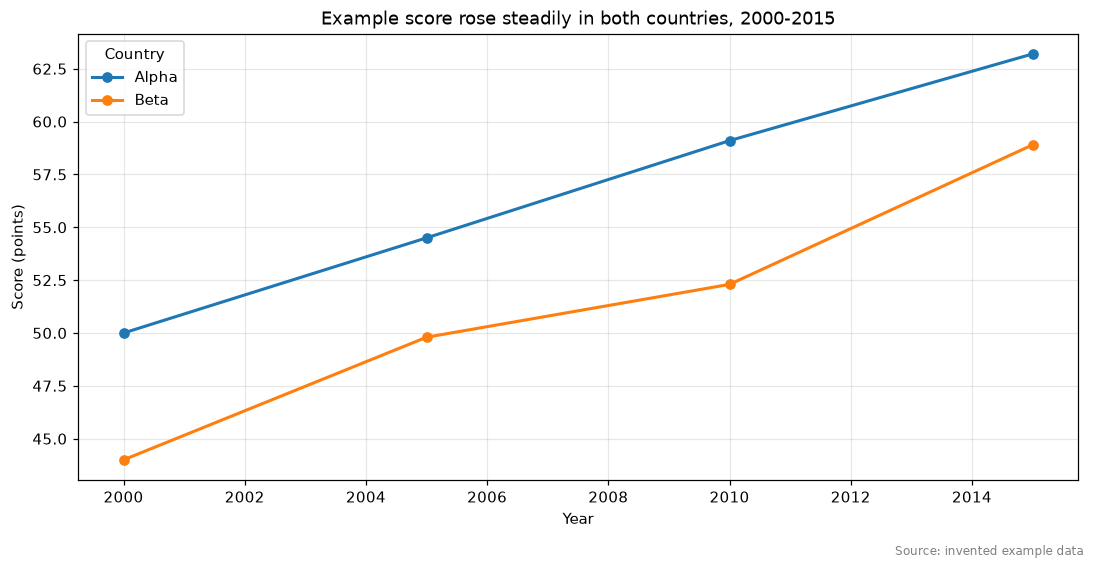

In [18]:
# WORKED EXAMPLE - invented numbers, shown for the pattern only.
example_df = pd.DataFrame({
    "country": ["Alpha"] * 4 + ["Beta"] * 4,
    "year": [2000, 2005, 2010, 2015] * 2,
    "score": [50.0, 54.5, 59.1, 63.2, 44.0, 49.8, 52.3, 58.9],
})

fig, ax = plt.subplots()

# One line per country. Looping over the groups keeps colours and the legend
# consistent, and works for any number of countries.
for country, group in example_df.groupby("country"):
    group = group.sort_values("year")          # a line chart must be in order
    ax.plot(group["year"], group["score"],
            marker="o", linewidth=2, label=country)

ax.set_title("Example score rose steadily in both countries, 2000-2015")
ax.set_xlabel("Year")
ax.set_ylabel("Score (points)")
ax.legend(title="Country")
ax.grid(True, alpha=0.3)                        # faint grid, easier to read
fig.text(0.99, -0.02, "Source: invented example data", ha="right", fontsize=8,
         color="grey")
fig.tight_layout()                              # stops labels being cut off
plt.show()

In [19]:
def plot_line_trend(df, country_column, year_column, value_column,
                    value_label, title, source_note, save_path=None):
    """Draw a line chart of the measure over time, one line per country.

    Returns
    -------
    matplotlib.axes.Axes
        So the caller can adjust the chart further if needed.
    """
    fig, ax = plt.subplots()

    # TODO 53: Draw one line per country, sorting each group by year first.
    for country, group in df.groupby(country_column):
        group = group.sort_values(year_column)

        ax.plot(
            group[year_column],
            group[value_column],
            marker="o",
            linewidth=2,
            label=country
        )

    # TODO 54: Set title, axis labels, and legend
    ax.set_title(title)
    ax.set_xlabel("Year (years)")
    ax.set_ylabel(value_label)
    ax.legend(title="Country")

    # TODO 55: Add source note, faint grid, and tidy layout
    ax.grid(True, alpha=0.3)

    fig.text(
        0.99,
        -0.02,
        f"Source: {source_note}",
        ha="right",
        fontsize=8,
        color="grey"
    )

    fig.tight_layout()

    # TODO 56: Save if save_path was given
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    # TODO 57: Return ax
    return ax


def plot_bar_ranking(df, country_column, value_column, value_label, title,
                     source_note, save_path=None):
    """Draw a bar chart ranking countries by the measure.

    Expects one row per country, already sorted.
    """
    fig, ax = plt.subplots()

    # TODO 58: Draw bars and label every bar
    bars = ax.bar(
        df[country_column],
        df[value_column]
    )

    ax.bar_label(
        bars,
        fmt="%.1f"
    )

    # TODO 59: Set title, axis labels, rotate tick labels,
    # add source note, and tidy layout
    ax.set_title(title)
    ax.set_xlabel("Country")
    ax.set_ylabel(value_label)

    ax.tick_params(axis="x", rotation=45)

    fig.text(
        0.99,
        -0.02,
        f"Source: {source_note}",
        ha="right",
        fontsize=8,
        color="grey"
    )

    fig.tight_layout()

    # TODO 60: Save if save_path was given
    if save_path is not None:
        fig.savefig(save_path, dpi=150, bbox_inches="tight")

    return ax

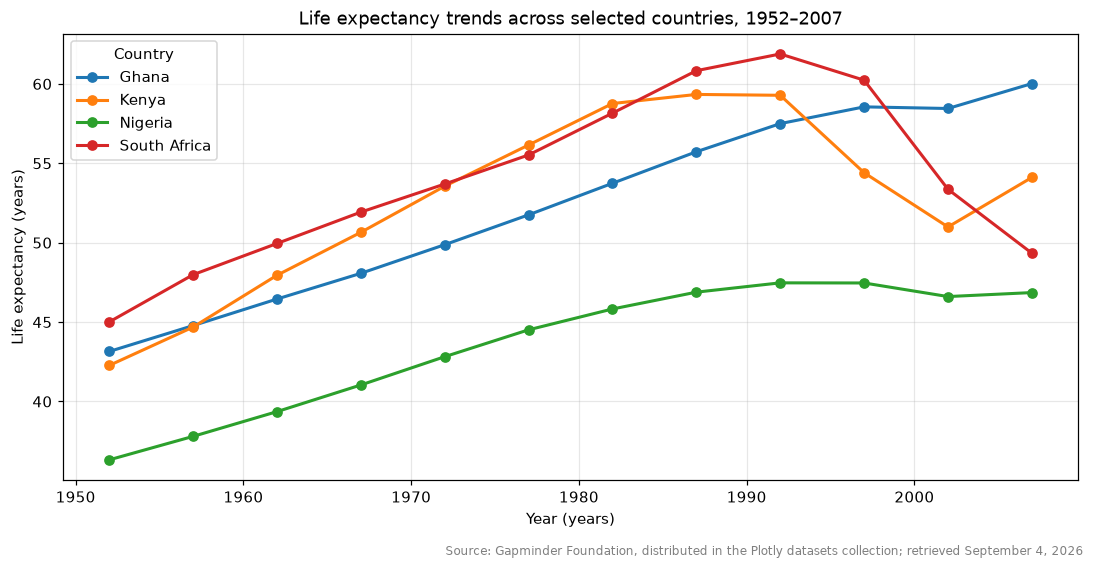

<Axes: title={'center': 'Countries ranked by life expectancy in 2007'}, xlabel='Country', ylabel='Life expectancy (years)'>

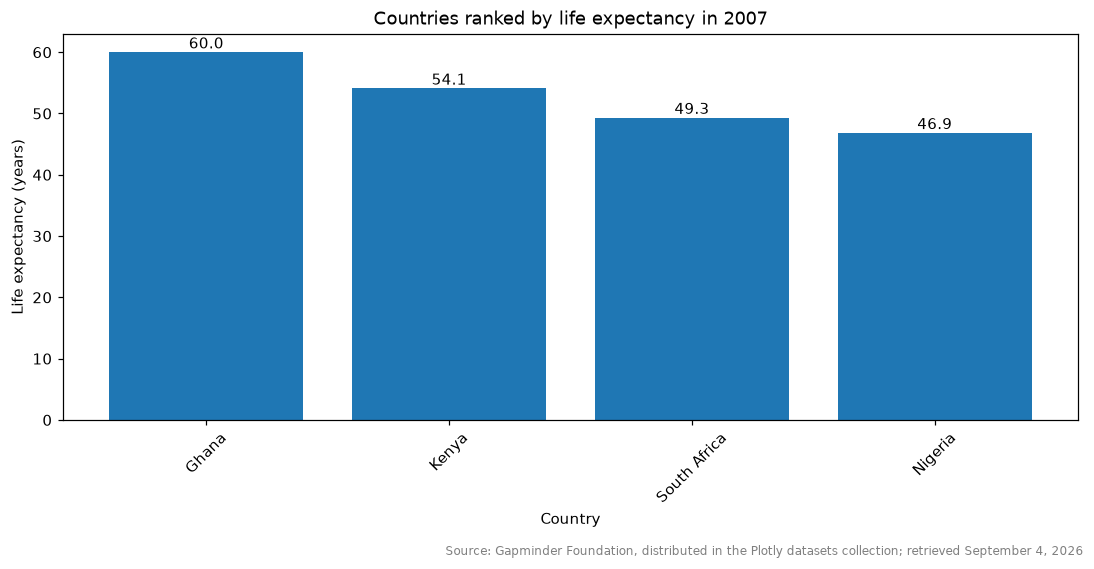

In [20]:
# TODO 61: Draw your line chart

line_chart_path = CHART_DIR / "life_expectancy_trend.png"

plot_line_trend(
    clean_df,
    "country",
    "year",
    "life_expectancy_years",
    "Life expectancy (years)",
    "Life expectancy trends across selected countries, 1952–2007",
    "Gapminder Foundation, distributed in the Plotly datasets collection; retrieved September 4, 2026",
    line_chart_path
)

plt.show()


# TODO 62: Draw your bar chart for the last year

last_year = clean_df["year"].max()

top_countries = top_n_in_year(
    clean_df,
    last_year,
    "life_expectancy_years"
)

bar_chart_path = CHART_DIR / "life_expectancy_ranking.png"

plot_bar_ranking(
    top_countries,
    "country",
    "life_expectancy_years",
    f"Life expectancy (years)",
    f"Countries ranked by life expectancy in {last_year}",
    "Gapminder Foundation, distributed in the Plotly datasets collection; retrieved September 4, 2026",
    bar_chart_path
)


### Your answer - reading your own charts

1. State in one sentence what the line chart shows. Include at least two numbers. [The line graph shows that all four countries experienced an overall improvement in life expectancy from 1952 to 1990, followed by a decline in the early 2000s and a recovery afterward, with Ghana and Kenya showing noticeable declines after 1990.]
2. State in one sentence what the bar chart shows. Include at least two numbers. [Ghana has the highest life expectancy of 60 years followed by Kenya while Nigeria recoreded the least life expectancy rate of 46.9 years in 2007]
3. Why is a line chart the right choice for the first question and a bar chart for the second? [A line chart connects the values across the years, making the trend and direction of change easy to see. A bar chart makes it easy to compare the size of each country's value and see the ranking.]
4. Look hard at your line chart. Is there a point where a line changes direction sharply, or a gap where data is missing? What might explain it, and what would you need in order to check? [After 1990, both Ghana and Kenya show a noticeable decline in life expectancy. However, after 2000, life expectancy begins to improve in both countries. This sharp decline could be related to major health, social, or economic challenges during that period, while the later improvement may reflect better healthcare and living conditions.]

---
## Part 10 - Optional: explore further

This part is not graded and is here because you should get into the habit of looking beyond what you were asked for.

Try one or more of the following, and write a sentence about what it showed you that the required charts did not:

- a **scatter plot** with `ax.scatter()`, if your dataset has two numeric measures, to look at whether they move together;
- a **horizontal bar chart** with `ax.barh()`, which is easier to read when country names are long;
- a **histogram** with `ax.hist()`, to see the distribution of your measure across all countries in one year rather than only your three;
- **small multiples** with `plt.subplots(1, 3)`, giving each country its own panel on a shared scale;
- an **annotation** with `ax.annotate()`, pointing at the single most interesting moment in your line chart.

Keep the same labelling standards. An exploratory chart with no axis labels is a note to yourself, and notes to yourself have a way of ending up in reports.

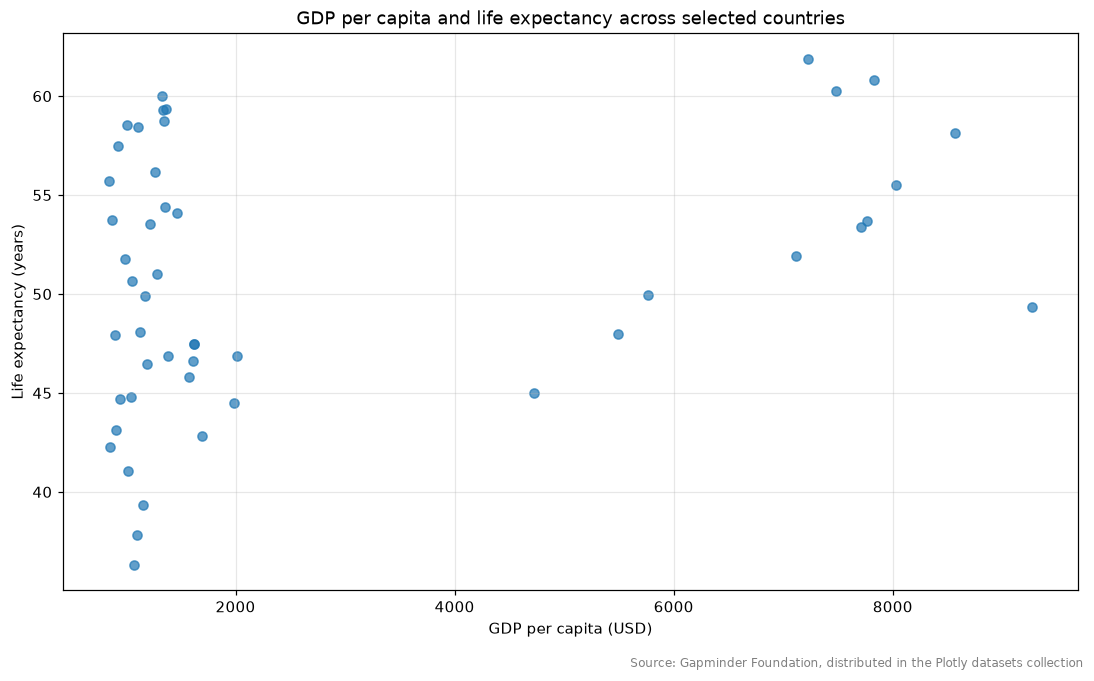

In [21]:
# OPTIONAL - not graded. Explore here.
#Scartter plot showing the GDP and life expectancy trend
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(
    clean_df["gdp_per_capita_usd"],
    clean_df["life_expectancy_years"],
    alpha=0.7
)

ax.set_title("GDP per capita and life expectancy across selected countries")
ax.set_xlabel("GDP per capita (USD)")
ax.set_ylabel("Life expectancy (years)")

ax.grid(True, alpha=0.3)

fig.text(
    0.99,
    -0.02,
    "Source: Gapminder Foundation, distributed in the Plotly datasets collection",
    ha="right",
    fontsize=8,
    color="grey"
)

fig.tight_layout()
plt.show()

The scatter plot showed the relationship between GDP per capita and life expectancy, revealing that countries with higher GDP per capita generally tend to have higher life expectancy, which the line and bar charts did not show.

---
## Part 11 - Write your manifest

A **manifest** is a small machine-readable file that records everything about the data in your project. It is what turns a folder of files into a documented dataset. Include the raw source, the cleaned output, and the steps between them.

Save it as JSON, because JSON is readable by both people and programs, and commit it alongside your data.

In [24]:
def build_manifest(source_record, clean_record, cleaning_notes, question,
                   countries, start_year, end_year):
    """Assemble a manifest describing this whole gathering exercise.

    Returns
    -------
    dict
        Structured with these top-level keys:
          "created_utc"      when the manifest was written
          "research_question"
          "focus_countries"
          "period"           a dict with "start" and "end"
          "raw_source"      the record from describe_source()
          "clean_output"   the record from save_clean_data()
          "cleaning_steps" a list of strings, one per decision you made
          "tools"          a dict of library names to versions
    """

    # TODO 63: Build and return the manifest dictionary
    return {
        "created_utc": datetime.now(timezone.utc).isoformat(),
        "research_question": question,
        "focus_countries": countries,
        "period": {
            "start": start_year,
            "end": end_year
        },
        "raw_source": source_record,
        "clean_output": clean_record,
        "cleaning_steps": cleaning_notes,
        "tools": {
            "pandas": pd.__version__
        }
    }

In [25]:


# TODO 64: Write your cleaning steps as a list of clear sentences
cleaning_notes = [
    "Renamed the columns to clear, lowercase names with underscores.",
    "Converted year to integer and numerical measures to float.",
    "Kept only the selected focus countries and the years 1952 to 2007.",
    "Dropped rows with missing life expectancy values because missing values should not be treated as zero.",
    "Removed exact duplicate rows to avoid counting the same observation more than once.",
    "Created a population_billions column by converting population from people to billions.",
    "Sorted the cleaned data by country and year and reset the index."
]

# Build the full source record (adds publisher, documentation, checksum)
source_record = describe_source(urllib_provenance, DATASET, checksum)

manifest = build_manifest(
    source_record,
    result,
    cleaning_notes,
    RESEARCH_QUESTION,
    FOCUS_COUNTRIES,
    START_YEAR,
    END_YEAR
)

manifest_path = DATA_DIR / "manifest.json"

with open(manifest_path, "w", encoding="utf-8") as file:
    json.dump(manifest, file, indent=2)

with open(manifest_path, "r", encoding="utf-8") as file:
    print(file.read())

{
  "created_utc": "2026-09-08T23:26:38.221479+00:00",
  "research_question": "How has life expectancy in Ghana changed between 1952 and 2007 compared with Kenya, Nigeria, and South Africa?",
  "focus_countries": [
    "Ghana",
    "Kenya",
    "Nigeria",
    "South Africa"
  ],
  "period": {
    "start": 1952,
    "end": 2007
  },
  "raw_source": {
    "source_name": "Gapminder five-year country indicators",
    "source_url": "https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv",
    "publisher": "Gapminder Foundation, distributed in the Plotly datasets collection",
    "documentation": "https://www.gapminder.org/data/documentation/",
    "local_path": "/home/jovyan/work/notebooks/data_analysis_process/assignments/data/raw/gapminder_five_year_raw.csv",
    "retrieved_utc": "2026-09-08T23:26:03.664236+00:00",
    "sha256_checksum": "714f8a23e9d7429052a1e9b45d20b9adeb64f46c067ed46320e68182e4607b6d"
  },
  "clean_output": {
    "path": "/home/jovyan/work/no

---
## Part 12 - Your findings, and how to submit

### Write your findings

Answer in full sentences, in the cell below. Every claim needs a number attached to it.

1. **Answer your research question directly.** One paragraph, three to five sentences, containing at least three numbers from your analysis.
2. **The most surprising thing you found**, and why it surprised you.
3. **Three limitations of this data.** For each one, say what claim it stops you from making. "The data might be inaccurate" is not a limitation; "life expectancy before 1950 is a modelled estimate rather than a measurement, so I cannot treat the 1543 values as observations" is.
4. **What you would gather next**, and from which source, to strengthen this brief.
5. **One thing that went wrong** while you were doing this, and how you worked it out.

### Then submit

Full step-by-step instructions, written for Windows with no assumed knowledge, are in [the GitHub submission guide](../topic19d_appendix_submitting_with_github.ipynb). In summary:

1. Create a **public** GitHub repository named `itfy-data-gathering-download`.
2. Copy in this completed notebook, your `data/raw/` and `data/clean/` folders, your `charts/` folder, and your `manifest.json`.
3. Write a `README.md` using the template in the guide.
4. Commit with a clear message, then **push**.
5. Open your repository in a private browsing window to prove it is public.
6. Submit the repository link.

### Before you submit, check every line

- [ ] Every `# TODO` is complete and no `NotImplementedError` remains anywhere
- [ ] The notebook was run from top to bottom in order, and every output is visible
- [ ] Both charts appear, with titles, axis labels with units, legends, and source notes
- [ ] `data/raw/` holds the unmodified download, `data/clean/` holds the cleaned file
- [ ] `manifest.json` is present and complete
- [ ] Every "Your answer" cell is filled in - none still says `[your answer]`
- [ ] `README.md` is written
- [ ] The repository is public, and the link opens in a private window

### Your findings

**1. Answer to my research question:**

*(Life expectancy generally increased across the selected countries from 1952 to 2007, although Ghana and Kenya experienced a noticeable decline after 1990 before recovering after 2000. The scatter plot also showed a positive relationship between GDP per capita and life expectancy, suggesting that countries with higher GDP per capita generally tended to have higher life expectancy. However, this relationship does not prove that higher GDP per capita directly causes longer life expectancy.)*

**2. The most surprising thing I found:**

*(The most surprising thing I found was that Ghana had a high life expectancy rate compared with the other selected countries.)*

**3. Three limitations of this data:**

1. *(The most recent data is from 2007, so the dataset does not reflect more recent changes in life expectancy or GDP per capita.)*
2. *(Data was collected at five-year intervals rather than every year, so changes that occurred between the recorded years may not be captured.)*
3. *(The data shows relationships between GDP per capita and life expectancy, but it cannot prove that one factor directly causes changes in the other.)*

**4. What I would gather next, and from where:**

*(I would gather data on the life expectancy rate of Africa and compare it with the other continents in the world. I would get the data from Gapminder or the World Bank, as these provide reliable international development data.)*

**5. Something that went wrong, and how I worked it out:**

*(One thing that went wrong was getting a NameError because some variables had not been defined before I used them. I worked it out by going back to the earlier cells, running the setup cells in the correct order, and then running the code again.)*

---
## Marking rubric

| Area | What earns the marks | Marks |
|---|---:|---:|
| Question and dataset choice | A specific, answerable question; the right dataset for it; sensible countries and period | 8 |
| Download functions | Both functions complete, with caching, headers, timeout, status checking, and a returned dictionary rather than a print | 16 |
| Comparing urllib and requests | The comparison table completed from experience, and a real error message investigated | 6 |
| Provenance and checksum | `file_fingerprint()` and `describe_source()` correct; provenance questions answered | 10 |
| Inspection | A thorough audit; the grain of the data correctly identified and stated | 10 |
| Cleaning | All required steps; aggregate rows handled; missing values handled deliberately; every decision justified in the table | 16 |
| Saving and raw/clean separation | Cleaned file saved with a descriptive name and verified by reading it back; raw file untouched | 6 |
| Analysis functions | All three functions correct and used; the improvement question answered in code | 10 |
| Charts | Line and bar charts correct, fully labelled with units and source notes, and interpreted in words | 12 |
| Manifest | Complete, valid JSON, cleaning steps recorded as readable sentences | 4 |
| Findings and limitations | Numbers in every claim; limitations that name the claim they block | 8 |
| Repository, README, and commits | Public repository, correct structure, complete README, commit messages that describe changes | 8 |
| **Total** | | **110** |

Marks are lost for: code that runs but is never explained, charts without axis units, a raw file that has been edited, a manifest that says `TODO`, `NotImplementedError` left in the notebook, and a repository that is not public.

## References

### Your data sources
- [Gapminder data documentation](https://www.gapminder.org/data/documentation/)
- [Our World in Data - life expectancy](https://ourworldindata.org/life-expectancy)
- [World Bank GDP dataset on DataHub](https://datahub.io/core/gdp)

### Downloading files
- [Python `urllib.request` documentation](https://docs.python.org/3/library/urllib.request.html)
- [`requests` quickstart guide](https://requests.readthedocs.io/en/latest/user/quickstart/)
- [Python `hashlib` documentation](https://docs.python.org/3/library/hashlib.html)
- [Python `pathlib` documentation](https://docs.python.org/3/library/pathlib.html)

### pandas and matplotlib
- [`pandas.read_csv`](https://pandas.pydata.org/docs/reference/api/pandas.read_csv.html)
- [pandas group by user guide](https://pandas.pydata.org/docs/user_guide/groupby.html)
- [matplotlib `plot` - line charts](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.plot.html)
- [matplotlib `bar` - bar charts](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.bar.html)
- [matplotlib quick start guide](https://matplotlib.org/stable/users/explain/quick_start.html)

### Course material
- [Topic 19 - Data Gathering lesson](../topic19_data_gathering.ipynb)
- [Appendix - common data sources](../topic19b_appendix_common_data_sources.ipynb)
- [Appendix - reading dataset documentation](../topic19c_appendix_reading_dataset_documentation.ipynb)
- [Appendix - submitting your work with GitHub](../topic19d_appendix_submitting_with_github.ipynb)
- [Assignment 2 - gathering data from an API](topic19_assignment_api_gathering.ipynb)